<a href="https://colab.research.google.com/github/di-pal-w/adversarial-robustness-toolbox/blob/main/ART_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install adversarial-robustness-toolbox torch torchvision matplotlib numpy -q

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 628kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]


Dataset loaded
Model created

Training started...

Epoch 1 Loss: 318.86
Epoch 2 Loss: 144.80
Epoch 3 Loss: 99.56

Training complete

Accuracy Before Attack: 97.02%

ART classifier created

Generating adversarial examples...
Adversarial examples generated

Accuracy After Attack: 1.81%


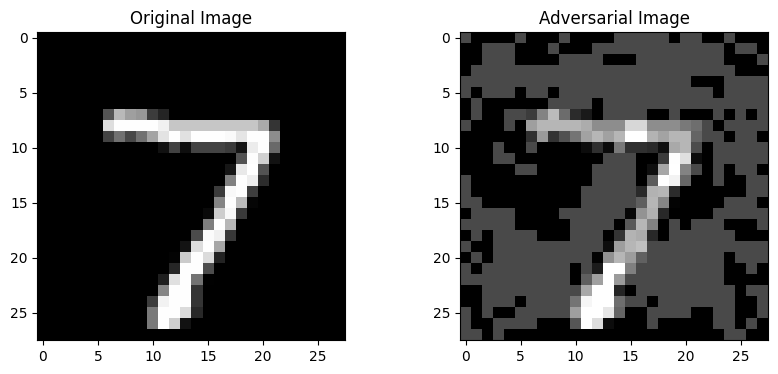


Original Prediction: 7
Adversarial Prediction: 3

Images saved successfully


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod

import numpy as np
import matplotlib.pyplot as plt

# =====================================
# 1. LOAD DATASET
# =====================================

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Dataset loaded")

# =====================================
# 2. CREATE MODEL
# =====================================

class SimpleNet(nn.Module):

    def __init__(self):
        super(SimpleNet, self).__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

model = SimpleNet()

print("Model created")

# =====================================
# 3. LOSS + OPTIMIZER
# =====================================

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# =====================================
# 4. TRAIN MODEL
# =====================================

print("\nTraining started...\n")

model.train()

for epoch in range(3):

    total_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.2f}")

print("\nTraining complete")

# =====================================
# 5. TEST BEFORE ATTACK
# =====================================

model.eval()

correct = 0
total = 0

x_test = []
y_test = []

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        x_test.append(images.numpy())
        y_test.append(labels.numpy())

accuracy = 100 * correct / total

print(f"\nAccuracy Before Attack: {accuracy:.2f}%")

# =====================================
# 6. CONVERT DATA
# =====================================

x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

# =====================================
# 7. WRAP MODEL USING ART
# =====================================

classifier = PyTorchClassifier(
    model=model,
    loss=loss_fn,
    optimizer=optimizer,
    input_shape=(1, 28, 28),
    nb_classes=10
)

print("\nART classifier created")

# =====================================
# 8. CREATE FGSM ATTACK
# =====================================

attack = FastGradientMethod(
    estimator=classifier,
    eps=0.2
)

print("\nGenerating adversarial examples...")

x_test_adv = attack.generate(x=x_test)

print("Adversarial examples generated")

# =====================================
# 9. TEST AFTER ATTACK
# =====================================

predictions = classifier.predict(x_test_adv)

predicted_labels = np.argmax(predictions, axis=1)

adv_accuracy = np.sum(
    predicted_labels == y_test
) / len(y_test)

adv_accuracy *= 100

print(f"\nAccuracy After Attack: {adv_accuracy:.2f}%")

# =====================================
# 10. SHOW IMAGES
# =====================================

index = 0

plt.figure(figsize=(10,4))

# ORIGINAL IMAGE

plt.subplot(1,2,1)

plt.imshow(
    x_test[index][0],
    cmap="gray"
)

plt.title("Original Image")

# ADVERSARIAL IMAGE

plt.subplot(1,2,2)

plt.imshow(
    x_test_adv[index][0],
    cmap="gray"
)

plt.title("Adversarial Image")

plt.show()

# =====================================
# 11. PREDICTIONS
# =====================================

original_prediction = classifier.predict(
    np.expand_dims(x_test[index], axis=0)
)

adv_prediction = classifier.predict(
    np.expand_dims(x_test_adv[index], axis=0)
)

print(
    "\nOriginal Prediction:",
    np.argmax(original_prediction)
)

print(
    "Adversarial Prediction:",
    np.argmax(adv_prediction)
)

# =====================================
# 12. SAVE IMAGES
# =====================================

plt.imsave(
    "original.png",
    x_test[index][0],
    cmap="gray"
)

plt.imsave(
    "adversarial.png",
    x_test_adv[index][0],
    cmap="gray"
)

print("\nImages saved successfully")